# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

The dataset contains web-session behaviour features, visitor/session details and the binary target variable `Revenue`, which shows whether a session ended in a purchase.

## Imports and settings

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# A fixed random state is used so that the train/test split and model results are reproducible.
RANDOM_STATE = 42

## Initial data examination

In [133]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

## Initial inspection

In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [135]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(125)

There are 125 exact duplicate rows in the dataset. Because these rows match across all columns, including the target variable, they are unlikely to add new information for model training. I inspect them before deciding how to handle them.

In [136]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

duplicate_rows_summary = pd.DataFrame({
    "duplicate_rows_including_originals": [len(duplicate_rows)],
    "duplicate_groups": [duplicate_rows.groupby(list(df.columns)).ngroups],
    "max_repeated_group_size": [
        duplicate_rows.groupby(list(df.columns)).size().max()
    ],
    "purchase_duplicates": [duplicate_rows["Revenue"].sum()],
    "non_purchase_duplicates": [(duplicate_rows["Revenue"] == False).sum()],
    "max_product_duration_in_duplicates": [
        duplicate_rows["ProductRelated_Duration"].max()
    ]
})

duplicate_rows_summary

,duplicate_rows_including_originals,duplicate_groups,max_repeated_group_size,purchase_duplicates,non_purchase_duplicates,max_product_duration_in_duplicates
0,201,76,14,0,201,0.0


The duplicate inspection shows that 201 rows are involved in exact duplicate groups, representing 76 repeated row patterns. The largest repeated pattern appears 14 times. All duplicated rows are non-purchase sessions, and the maximum `ProductRelated_Duration` among them is 0.0.

Because the repeated rows are exact matches and all belong to the majority class, keeping them would slightly strengthen the existing class imbalance without adding new information. I drop these duplicate rows before modelling.

In [137]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

After removing exact duplicates, the dataset contains 12,205 rows. The duplicate removal does not remove any purchase sessions, but it reduces repeated non-purchase records. The target remains imbalanced, so the evaluation strategy still prioritises F1-score, recall, precision and the confusion matrix rather than accuracy alone.

## EDA and target imbalance

In [138]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. The later evaluation therefore uses precision, recall, F1-score and a confusion matrix, not just accuracy.

The next check examines the numerical feature distributions to understand the scale and spread of the input variables.

In [139]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have very different ranges. Duration features such as `ProductRelated_Duration` are much larger than rate features such as `BounceRates` and `ExitRates`.

This matters because some candidate models are sensitive to feature scale. The preprocessing pipeline scales the numerical columns rather than changing the raw dataset directly.

In [140]:
df.sort_values("ProductRelated_Duration", ascending=False).head(10)[
    ["ProductRelated", "ProductRelated_Duration", "PageValues", "BounceRates", "ExitRates", "Revenue"]
]

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates,Revenue
7983,449,63973.52223,0.000000,0.000764,0.027701,False
5074,705,43171.23338,0.763829,0.004851,0.015431,False
9149,343,29970.46597,0.000000,0.005316,0.028971,False
8695,517,27009.85943,8.403164,0.004385,0.014594,True
8220,584,24844.15620,4.511100,0.002099,0.009347,False
7574,414,23888.81000,1.033757,0.009900,0.027062,False
6599,686,23342.08205,0.150650,0.009853,0.022771,False
6080,486,23050.10414,0.000000,0.000324,0.011249,False
5831,439,21857.04648,11.439233,0.003589,0.012498,False
8883,501,21672.24425,9.131387,0.003965,0.014292,True


The longest `ProductRelated_Duration` values are not exact duplicates. They appear to be unusual but valid browsing sessions rather than repeated logging errors.

The highest value is around 63,974 seconds, or about 17.8 hours. This is extreme, but the rows also have different values for `ProductRelated`, `PageValues`, `BounceRates`, `ExitRates` and `Revenue`, so they are not identical records. I keep these rows because long session durations can occur in web analytics data, especially if a session remains open in the browser.

In [141]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3329
VisitorType,3,Returning_Visitor,10431
Weekend,2,False,9346
OperatingSystems,8,2,6541
Browser,13,2,7883
Region,9,1,4714
TrafficType,20,2,3911


This table shows the number of unique values in each categorical or coded feature. `Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region` and `TrafficType` are treated as categorical inputs. Although some of them are stored as numbers, they represent category codes rather than measured quantities, so they are one-hot encoded instead of treated as ordered values.

In [142]:
for col in categorical_cols:
    display(
        df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("percentage")
        .to_frame()
    )

,percentage
Month,
May,27.28
Nov,24.43
Mar,15.24
Dec,13.98
Oct,4.50
Sep,3.67
Aug,3.55
Jul,3.54
June,2.34


,percentage
VisitorType,
Returning_Visitor,85.46
New_Visitor,13.87
Other,0.66


,percentage
Weekend,
False,76.58
True,23.42


,percentage
OperatingSystems,
2,53.59
1,20.88
3,20.73
4,3.92
8,0.61
6,0.16
7,0.06
5,0.05


,percentage
Browser,
2,64.59
1,19.89
4,5.99
5,3.81
6,1.43
10,1.34
8,1.11
3,0.86
13,0.46


,percentage
Region,
1,38.62
3,19.49
4,9.59
2,9.24
6,6.56
7,6.21
9,4.14
8,3.53
5,2.61


,percentage
TrafficType,
2,32.04
1,19.57
3,16.49
4,8.73
13,5.96
10,3.69
6,3.63
8,2.81
5,2.13


The categorical columns are not evenly spread. Most sessions are from `Returning_Visitor` users, at 85.46%, while `New_Visitor` users only make up 13.87%. The `Weekend` column is also uneven, with 76.58% of sessions not taking place at the weekend.

Some of the coded categories are heavily concentrated in one or two values. For example, `Browser` value 2 makes up 64.59% of sessions, and `OperatingSystems` value 2 makes up 53.59%. `TrafficType` is less extreme, but values 2, 1 and 3 still account for most sessions.

This means the categorical data is quite skewed. Some categories have plenty of examples for the model to learn from, while others appear very rarely. Because these columns are category labels rather than real measurements, they are encoded as categorical variables in the preprocessing step.

In [143]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. This is checked later using feature importance and model results.

### Exploratory visualisation

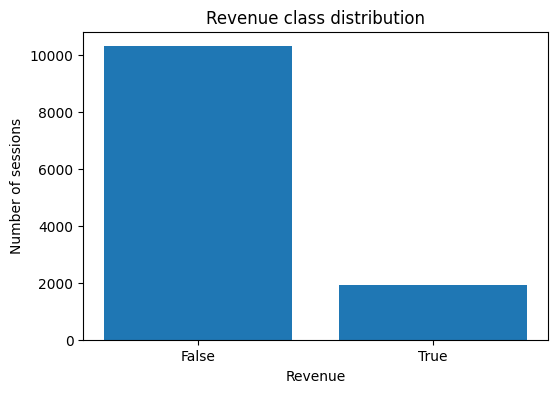

In [144]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. The later evaluation also uses precision, recall, F1-score and a confusion matrix.

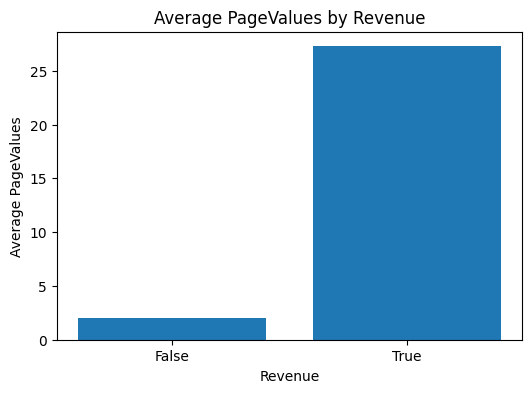

In [145]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. This is checked again later when comparing feature importance and model performance.

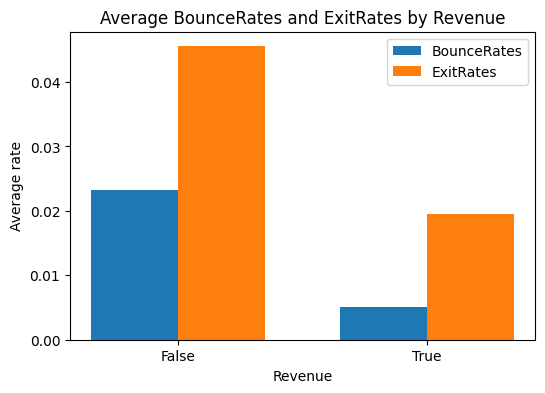

In [146]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Preprocessing plan

The models need a consistent preprocessing step because the dataset contains mixed feature types. Numerical browsing-behaviour columns will be standardised, while text, Boolean and coded category columns will be one-hot encoded.

Preprocessing is kept inside each model pipeline so the transformations are fitted only on the training data during model development.

## Feature and target split

In [147]:
# Separate the input features from the target variable
X_original = df.drop(columns=["Revenue"])
y = df["Revenue"]

print("Feature data shape:", X_original.shape)
print("Target data shape:", y.shape)

Feature data shape: (12205, 17)
Target data shape: (12205,)


I split the dataset into features and target. `X_original` contains the 17 input features, and `y` contains the target variable, `Revenue`.

This makes the classification target explicit before preprocessing and model training.

In [148]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


The target balance is checked again before splitting the data.

Because the classes are imbalanced, a stratified train-test split is used so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [149]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features_original = [
    col for col in X_original.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_original)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, one Boolean value and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

`Weekend` is included with the categorical features because it describes the type of session rather than measuring a continuous value. Since it simply indicates whether the visit happened on a weekend or not, it makes sense to treat it like the other categorical variables. Similarly, features such as `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are treated as categorical because their numbers are just labels for different groups, not values with a meaningful order.

In [150]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_original.shape)
print("Test features:", X_test_original.shape)
print("Training target:", y_train_original.shape)
print("Test target:", y_test_original.shape)

Training features: (9764, 17)
Test features: (2441, 17)
Training target: (9764,)
Test target: (2441,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

An 80/20 train-test split is used so that most of the dataset is available for model training, while still keeping a separate unseen test set for final evaluation. The split uses `stratify=y` because the target variable is imbalanced. Stratification keeps the class balance similar in both sets, which makes the evaluation fairer.

In [151]:
split_balance = pd.DataFrame({
    "train_percentage": y_train_original.value_counts(normalize=True) * 100,
    "test_percentage": y_test_original.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.371159,84.350676
True,15.628841,15.649324


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

## Preprocessing setup

In [152]:
preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_original),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor_original)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The origibal-feature preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares all features as numerical inputs for the classifiers.

## Feature Selection

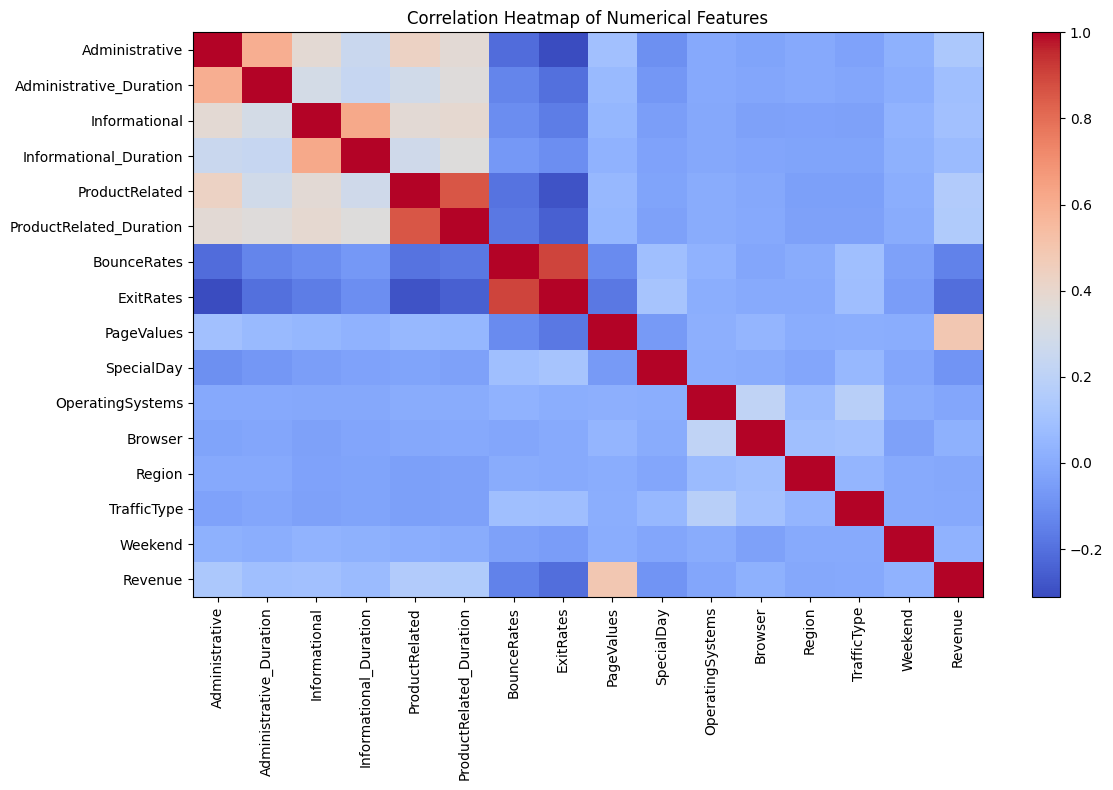

In [153]:
# Create a correlation matrix for the numerical columns
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The correlation check reinforces that `PageValues` has the strongest positive relationship with `Revenue`. `ProductRelated` and `ProductRelated_Duration` are also positively related to purchases.

`ExitRates` and `BounceRates` have negative correlations with `Revenue`. This is consistent with the idea that sessions where users leave quickly are less likely to end in a purchase, although correlation only shows association rather than causation.

Some features, such as `Administrative`, `Informational`, `SpecialDay` and `Informational_Duration`, show weaker direct correlations with `Revenue`. These features may still be useful in combination with others, but their individual linear relationship with the target is weaker. Correlation is therefore used as a simple filter check, while mutual information is used next as a broader feature selection method.

## Feature selection with mutual information

Mutual information is used as a filter-based feature selection check. It is fitted only on the training data to avoid using information from the test set during model development. 

In [154]:
mi_preprocessor = clone(preprocessor_original)

X_train_processed = mi_preprocessor.fit_transform(X_train_original)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_original,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_df.head(15)

,feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765
5,num__Administrative,0.017184
6,cat__Month_Nov,0.013419
7,num__SpecialDay,0.009886
8,cat__TrafficType_15,0.009080
9,num__Administrative_Duration,0.008649


The mutual information scores suggest that `PageValues` is by far the strongest individual feature, with a score of 0.163820. There is a clear drop after this. The next highest features are `ExitRates` at 0.037809, `ProductRelated_Duration` at 0.032262 and `BounceRates` at 0.020914.

This makes sense for this dataset. `PageValues` is linked to the estimated value of pages visited before a transaction, so it is closely connected to purchase behaviour. The other high-ranking features are also mainly about how users behaved during the session, such as whether they stayed on product pages, left quickly, or exited the site.

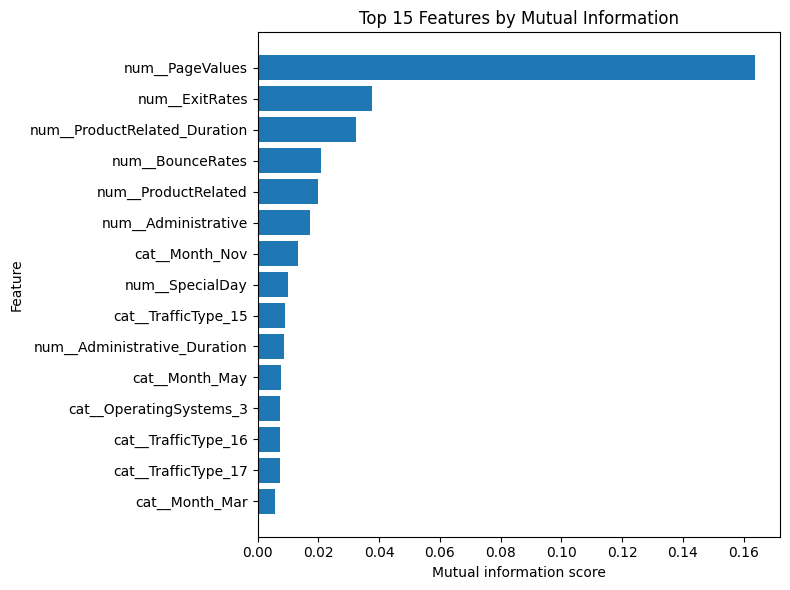

In [155]:
top_mi_features = mi_scores_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

The chart makes the same pattern easier to see. `PageValues` stands out clearly, while the rest of the features have much smaller mutual information scores.

Most of the top features are numerical browsing-behaviour features, including `ExitRates`, `ProductRelated_Duration`, `BounceRates`, `ProductRelated`, `Administrative_Duration` and `Administrative`. A few one-hot encoded categorical features also appear, such as `Month_Nov`, `VisitorType_New_Visitor`, `Month_May`, `OperatingSystems_5`, `Region_1` and `Month_Oct`.

This suggests that the strongest signal comes from what the visitor actually did during the session. Timing and visitor type still seem useful, but they are not as strong as the direct behavioural features.

Feature selection was used to identify the variables most associated with the target and to provide insight into the dataset before model construction.

In [156]:
# A top-k value of 15 was used at this stage to inspect a manageable subset of 
# the most informative processed features. This is not treated as the final 
# feature set for modelling. Instead, it provides early evidence about which variables 
# appear most related to the target before the candidate classifiers are introduced.

TOP_K_FEATURES = 15

def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

selected_feature_selector = SelectKBest(
    score_func=reproducible_mutual_info,
    k=TOP_K_FEATURES
)

selected_feature_selector.fit(X_train_processed, y_train_original)

selected_features_df = (
    pd.DataFrame({
        "selected_feature": processed_feature_names[selected_feature_selector.get_support()],
        "mutual_information": selected_feature_selector.scores_[selected_feature_selector.get_support()]
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

selected_features_df

,selected_feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765
5,num__Administrative,0.017184
6,cat__Month_Nov,0.013419
7,num__SpecialDay,0.009886
8,cat__TrafficType_15,0.009080
9,num__Administrative_Duration,0.008649


The `SelectKBest` table shows the 15 processed features with the highest mutual information scores, fitted on the training data only.

Most of the selected features relate to browsing behaviour, including `PageValues`, `ExitRates`, duration measures and product-related activity. Some one-hot encoded month and traffic features are also selected, suggesting that timing and traffic source may provide smaller supporting signals.

This section is used as feature-selection evidence rather than as the final modelling feature set. The full feature set is still tested later, because features with weaker individual scores may still contribute useful information when combined with other variables.

## Candidate machine learning models

This is a supervised binary classification task because each session has a known `Revenue` label.

The baseline comparison uses a mix of classifier types: `Logistic Regression`, `Decision Tree`, `Random Forest`, `Gradient Boosting`, `Hist Gradient Boosting`, `Support Vector Machine`, `K-Nearest Neighbours` and `MLPClassifier`. This gives linear, tree-based, ensemble, kernel-based, distance-based and neural-network comparisons before tuning.

## Baseline model comparison

Several baseline classification models are tested using the same train-test split and preprocessing approach.

Because the target is imbalanced, accuracy is recorded but the comparison focuses more on F1-score, recall, precision and the confusion matrix.

The baseline models are trained using default or lightly adjusted settings. For models that support it cleanly, `class_weight="balanced"` is used so that the smaller purchase class receives more weight during training.

In [157]:
# Baseline models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLPClassifier": MLPClassifier(
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

`class_weight="balanced"` is used for models where it works well, such as Logistic Regression, Decision Tree, Random Forest, and SVM. It helps the model pay more attention to the smaller purchase class by giving it extra weight. Since not all models handle this setting in the same way, class imbalance is also addressed through stratified splitting and by focusing on F1-score, precision, and recall instead of accuracy alone.

In [158]:
def evaluate_model(model_name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, y_pred, cm

In [159]:
baseline_results = []
trained_pipelines = {}
baseline_predictions = {}
baseline_confusion_matrices = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_original)),
        ("model", clone(model))
    ])

    pipeline.fit(X_train_original, y_train_original)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_original,
        y_test_original
    )

    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline
    baseline_predictions[model_name] = y_pred
    baseline_confusion_matrices[model_name] = cm



Logistic Regression
Confusion matrix:
[[1761  298]
 [  78  304]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.86      0.90      2059
        True       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441


Decision Tree
Confusion matrix:
[[1897  162]
 [ 190  192]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.92      0.92      2059
        True       0.54      0.50      0.52       382

    accuracy                           0.86      2441
   macro avg       0.73      0.71      0.72      2441
weighted avg       0.85      0.86      0.85      2441


Random Forest
Confusion matrix:
[[1993   66]
 [ 192  190]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [160]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590
4,Support Vector Machine,0.868906,0.558935,0.769634,0.647577
0,Logistic Regression,0.845965,0.504983,0.795812,0.617886
7,MLPClassifier,0.878329,0.617729,0.583770,0.600269
2,Random Forest,0.894306,0.742188,0.497382,0.595611
1,Decision Tree,0.855797,0.542373,0.502618,0.521739
3,K-Nearest Neighbours,0.873413,0.662222,0.390052,0.490939


The baseline comparison shows that the models behave quite differently on the purchase class.

`Hist Gradient Boosting` has the best F1-score for the `True` class, at about `0.67`, and the highest accuracy at about `0.90`. Its precision is about `0.73` and recall is about `0.63`, so it gives the strongest overall balance in the baseline comparison.

`Gradient Boosting` performs almost the same as `Hist Gradient Boosting`, with accuracy of about `0.90` and an F1-score of about `0.67` for the `True` class. Its precision is about `0.71` and recall is about `0.63`. This shows that the standard boosting model is also a strong baseline, but in this test it is slightly behind `Hist Gradient Boosting`.

`Support Vector Machine` also has strong recall, at about `0.77`, and a better F1-score than `Logistic Regression`, at about `0.65`. This makes it a useful comparison model, although its precision is still lower than the boosting models.

`Logistic Regression` has the highest recall for the purchase class, at about `0.80`, which means it finds the most actual purchase sessions. However, its precision is much lower, at about `0.50`, so it also makes more false purchase predictions.

`Random Forest` has the highest precision for the purchase class, at about `0.74`, but recall is much lower at about `0.50`. This means it gives fewer false purchase predictions, but misses about half of the real purchases.

`Decision Tree` and `K-Nearest Neighbours` are weaker overall on F1-score. `MLPClassifier` performs reasonably, but it gives a convergence warning, so it needs more tuning before being judged properly.


Based on this first comparison, `Hist Gradient Boosting`, `Gradient Boosting`, `Support Vector Machine`, `Logistic Regression` and `Random Forest` look most worth continuing with. The boosting models have the strongest F1-scores, the linear and SVM models have strong recall, and `Random Forest` has strong precision.

`MLPClassifier` is kept as a comparison because it represents a different model family, although the baseline result does not outperform the strongest models.

## Feature Importance Analysis

Feature importance is checked before tuning to get an initial model-based view of which inputs are most influential.

This check uses `Gradient Boosting` because it is one of the strongest baseline models and provides a straightforward built-in feature importance measure. The result is used as an exploratory check only, not as the final explanation of the selected model.

Features are not removed automatically just because they have lower importance, as weaker individual features may still help when combined with others.

In [161]:
gb_pipeline = trained_pipelines["Gradient Boosting"]

gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]
feature_names = gb_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.746017
17,cat__Month_Nov,0.044649
6,num__BounceRates,0.043008
5,num__ProductRelated_Duration,0.034506
0,num__Administrative,0.030777
7,num__ExitRates,0.025386
1,num__Administrative_Duration,0.014230
4,num__ProductRelated,0.013252
16,cat__Month_May,0.008298
22,cat__VisitorType_Returning_Visitor,0.006751


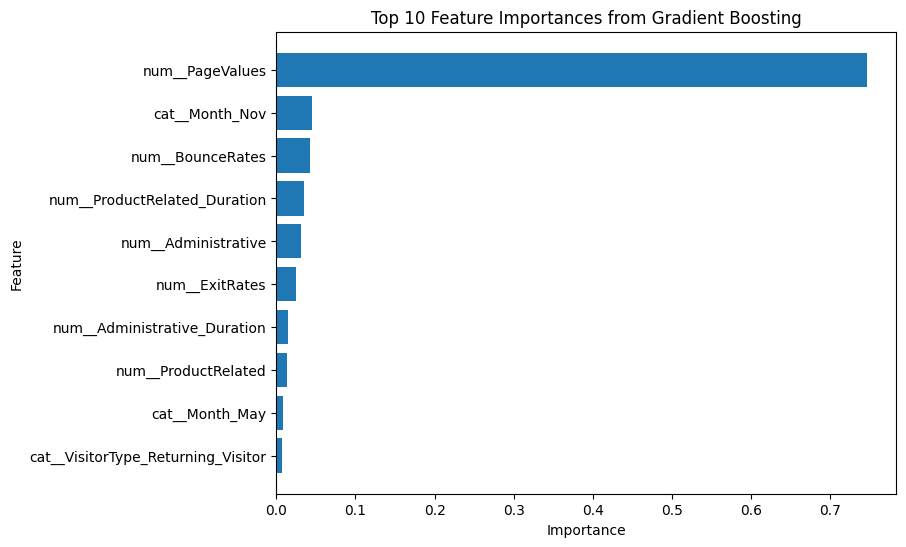

In [162]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance plot shows that `PageValues` is by far the strongest feature in the Gradient Boosting model.

After `PageValues`, the next most important features are `BounceRates`, `Month_Nov`, `Administrative`, `ExitRates`, `ProductRelated_Duration` and `ProductRelated`. This partly supports the earlier analysis, because `BounceRates`, `ExitRates` and product-related activity all relate to how users move through the website.

`Month_Nov` being important may make sense because online shopping behaviour can change by month, especially around seasonal shopping periods. `Administrative` is also useful to note because it suggests that non-product browsing activity may still contain some signal.

This is only an exploratory importance check from one strong baseline model. The final model explanation is checked later using permutation importance on the leading tuned contenders.

## Diagnostic check: model dependence on `PageValues`

The feature importance results show that `PageValues` is the strongest feature in the `Gradient Boosting` model. This diagnostic check compares the same model with and without `PageValues` using cross-validation on the training data only.

In [163]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train_with_pagevalues = X_train_original.copy()
X_train_without_pagevalues = X_train_original.drop(columns=["PageValues"])

numerical_features_without_pagevalues = [
    col for col in numerical_features_original
    if col != "PageValues"
]

preprocessor_with_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_original),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_without_pagevalues = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_without_pagevalues),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Same model used in both experiments
gb_with_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_with_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_without_pagevalues_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_without_pagevalues),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_with_pagevalues = cross_validate(
    gb_with_pagevalues_pipeline,
    X_train_with_pagevalues,
    y_train_original,
    cv=cv,
    scoring=scoring
)

cv_without_pagevalues = cross_validate(
    gb_without_pagevalues_pipeline,
    X_train_without_pagevalues,
    y_train_original,
    cv=cv,
    scoring=scoring
)

pagevalues_cv_comparison = pd.DataFrame({
    "With PageValues": [
        cv_with_pagevalues["test_accuracy"].mean(),
        cv_with_pagevalues["test_precision"].mean(),
        cv_with_pagevalues["test_recall"].mean(),
        cv_with_pagevalues["test_f1"].mean()
    ],
    "Without PageValues": [
        cv_without_pagevalues["test_accuracy"].mean(),
        cv_without_pagevalues["test_precision"].mean(),
        cv_without_pagevalues["test_recall"].mean(),
        cv_without_pagevalues["test_f1"].mean()
    ]
}, index=["accuracy", "precision", "recall", "f1"])

pagevalues_cv_comparison["Difference"] = (
    pagevalues_cv_comparison["Without PageValues"]
    - pagevalues_cv_comparison["With PageValues"]
)

pagevalues_cv_comparison

,With PageValues,Without PageValues,Difference
accuracy,0.902192,0.845862,-0.056330
precision,0.728340,0.550415,-0.177925
recall,0.597634,0.079310,-0.518324
f1,0.656280,0.138221,-0.518059


Removing `PageValues` causes a large drop in purchase-class performance. The F1-score and recall fall much more than accuracy, which shows why accuracy is not enough for this imbalanced dataset.

This suggests that `PageValues` carries important predictive information. It is kept in the modelling pipeline, but the final limitations section notes that the final model depends strongly on this feature.

## Tuning original-feature models

After the baseline comparison, the strongest or most informative candidates are tuned using the original feature set. `RandomizedSearchCV` is used with 5-fold cross-validation on the training data and `scoring="f1"`, because F1-score balances precision and recall for the minority purchase class.

### Tuning Gradient Boosting

`Gradient Boosting` is tuned because it was one of the strongest baseline models. The search tests a small set of values for boosting stages, learning rate, tree depth and minimum leaf size.

In [164]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Best cross-validation F1-score:
0.6603656495665394


In [165]:
gb_tuned_results, gb_tuned_pred, gb_tuned_confusion = evaluate_model(
    "Tuned Gradient Boosting",
    gb_search,
    X_test_original,
    y_test_original
)

gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1964   95]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9041376485047112,
 'precision': 0.7189349112426036,
 'recall': 0.6361256544502618,
 'f1': 0.675}

The tuned `Gradient Boosting` model selected 200 boosting stages, a minimum leaf size of 1, a maximum tree depth of 3 and a learning rate of 0.05. Compared with the baseline model, this uses more boosting stages but a lower learning rate, so the model learns in smaller steps.

The tuned model gives a small improvement over the baseline `Gradient Boosting` result. Its recall and precision are both slightly stronger, so it remains one of the strongest contenders after tuning.

### Tuning Hist Gradient Boosting

`Hist Gradient Boosting` is tuned next because its baseline result was close to the standard `Gradient Boosting` model. The search tests boosting iterations, learning rate, tree size and regularisation.

In [166]:
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.1]
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
Best cross-validation F1-score:
0.6520259415075544


In [167]:
hgb_tuned_results, hgb_tuned_pred, hgb_tuned_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting",
    hgb_search,
    X_test_original,
    y_test_original
)

hgb_tuned_results


Tuned Hist Gradient Boosting
Confusion matrix:
[[1966   93]
 [ 144  238]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Hist Gradient Boosting',
 'accuracy': 0.9029086439983613,
 'precision': 0.7190332326283988,
 'recall': 0.6230366492146597,
 'f1': 0.667601683029453}

In [168]:
tuned_results = [
    gb_tuned_results,
    hgb_tuned_results
]

The tuned `Hist Gradient Boosting` model remains strong, but it does not move ahead of the standard tuned `Gradient Boosting` model. Its precision is still good, while recall is slightly weaker.

The next step is to tune models from other families to check whether a different precision-recall trade-off is possible.

### Tuning Support Vector Machine

`Support Vector Machine` is tuned because it had strong baseline recall. The search compares a linear kernel with an `rbf` kernel, different `C` values, `gamma` values for the `rbf` kernel, and optional class weighting.

In [169]:
svm_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", SVC(random_state=RANDOM_STATE))
])

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_grid,
    n_iter=12,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(svm_search.best_params_)
print("\nBest CV F1-score:")
print(svm_search.best_score_)

svm_tuned_results, svm_tuned_pred, svm_tuned_confusion = evaluate_model(
    "Tuned Support Vector Machine",
    svm_search,
    X_test_original,
    y_test_original
)

tuned_results.append(svm_tuned_results)

Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6535302362227585

Tuned Support Vector Machine
Confusion matrix:
[[1833  226]
 [  86  296]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



The tuned `Support Vector Machine` keeps high recall for the purchase class, but its precision remains lower than the strongest tree-based models.

This makes it useful as a high-recall comparison model, but not the best overall contender because it produces more false purchase predictions.

### Tuning Logistic Regression

`Logistic Regression` is tuned as the main interpretable linear comparison model. The search compares regularisation strength and `l1` versus `l2` penalties using the `liblinear` solver.

In [170]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        solver="liblinear"
    ))
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0, 1]
}

logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

logreg_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(logreg_search.best_params_)
print("\nBest CV F1-score:")
print(logreg_search.best_score_)

logreg_tuned_results, logreg_tuned_pred, logreg_tuned_confusion = evaluate_model(
    "Tuned Logistic Regression",
    logreg_search,
    X_test_original,
    y_test_original
)

tuned_results.append(logreg_tuned_results)

Best parameters:
{'model__l1_ratio': 1, 'model__C': 0.01}

Best CV F1-score:
0.6538501037749157

Tuned Logistic Regression
Confusion matrix:
[[1840  219]
 [  92  290]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2059
        True       0.57      0.76      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



The tuned `Logistic Regression` result provides a simple linear benchmark. It usually gives strong recall, but lower precision than the strongest tree-based models.

This means it is useful for interpretability and comparison, but it is unlikely to be selected as the final model unless its F1-score moves clearly ahead of the stronger tree-based results.

### Tuning Random Forest

`Random Forest` is tuned because the baseline model had strong precision but weaker recall. The search checks whether tree count, tree depth, feature sampling and class weighting can improve F1-score.

In [171]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(rf_search.best_params_)
print("\nBest CV F1-score:")
print(rf_search.best_score_)

rf_tuned_results, rf_tuned_pred, rf_tuned_confusion = evaluate_model(
    "Tuned Random Forest",
    rf_search,
    X_test_original,
    y_test_original
)

tuned_results.append(rf_tuned_results)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6814100869317385

Tuned Random Forest
Confusion matrix:
[[1927  132]
 [ 116  266]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.70      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Random Forest` selected 300 trees, `min_samples_split=5`, `min_samples_leaf=2`, `max_features="sqrt"`, `max_depth=20` and `class_weight="balanced"`. This suggests that the model benefited from using more trees, random feature subsets, controlled tree depth and class weighting.

For the purchase class, the tuned model achieved precision 0.67, recall 0.70 and F1-score 0.68. The confusion matrix shows that it correctly identified 266 purchase sessions and missed 116, while incorrectly classifying 132 non-purchase sessions as purchases.

Compared with the baseline `Random Forest`, the tuned model gave up some precision but improved recall substantially. The baseline model was too cautious and missed many actual purchase sessions. The tuned version is now one of the strongest models so far, with a better F1-score than the tuned `Gradient Boosting`, `Hist Gradient Boosting`, `Support Vector Machine` and `Logistic Regression` results.

### Tuning MLPClassifier

`MLPClassifier` is tuned as a neural-network comparison. The search increases `max_iter`, uses early stopping and tests network size, activation, regularisation strength and learning rate.

In [172]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_original)),
    ("model", MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=mlp_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

mlp_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(mlp_search.best_params_)
print("\nBest CV F1-score:")
print(mlp_search.best_score_)

mlp_tuned_results, mlp_tuned_pred, mlp_tuned_confusion = evaluate_model(
    "Tuned MLPClassifier",
    mlp_search,
    X_test_original,
    y_test_original
)

tuned_results.append(mlp_tuned_results)

Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'relu'}

Best CV F1-score:
0.6231569282250036

Tuned MLPClassifier
Confusion matrix:
[[1966   93]
 [ 156  226]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.59      0.64       382

    accuracy                           0.90      2441
   macro avg       0.82      0.77      0.79      2441
weighted avg       0.89      0.90      0.89      2441



The tuned `MLPClassifier` chose a small network: one hidden layer with 50 neurons, `relu` activation, `alpha=0.01` and `learning_rate_init=0.01`. Its best cross-validation F1-score was 0.623157.

On the test set, the purchase-class precision was 0.71, recall was 0.59 and F1-score was 0.64. It correctly predicted 226 purchase sessions, but missed 156, so the main weakness is still recall. Compared with the tuned `Random Forest`, `Support Vector Machine` and `Logistic Regression`, the MLP found fewer of the actual purchase sessions.

This was still a useful comparison because it showed that a neural network did not automatically perform better on this structured tabular dataset. The stronger results came from the tuned tree-based models, especially `Random Forest`.

In [173]:
tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051
0,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000
1,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602
2,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867
3,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954
5,Tuned MLPClassifier,0.897993,0.708464,0.591623,0.644793


In [174]:
tuned_results_df.sort_values(by="f1", ascending=False).to_csv(
    "../outputs/tuned_results_original_features.csv",
    index=False
)

`Tuned Random Forest` has the strongest F1-score in the original-feature tuning results. It improves recall compared with the baseline `Random Forest`, while keeping precision reasonable.

`Tuned Gradient Boosting` and `Tuned Hist Gradient Boosting` remain close, with slightly stronger precision but lower recall. The tuned linear and SVM models keep high recall, but their lower precision means they create more false purchase predictions.

## Feature engineering cycle

The first tuning cycle used the original feature set. The next cycle tests whether a small set of engineered behavioural features improves performance.

The engineered features summarise session size and product focus. They are tested as a controlled refinement rather than assumed to improve the model.

In [175]:
df_engineered = df.copy()

df_engineered["total_pages"] = (
    df_engineered["Administrative"]
    + df_engineered["Informational"]
    + df_engineered["ProductRelated"]
)

df_engineered["total_duration"] = (
    df_engineered["Administrative_Duration"]
    + df_engineered["Informational_Duration"]
    + df_engineered["ProductRelated_Duration"]
)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

df_engineered[
    [
        "total_pages",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,0.904126,0.851437
std,46.627336,2043.871589,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,0.857143,0.831101
50%,20.000000,690.958333,0.961538,0.968646
75%,42.000000,1643.958333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


The engineered features were created successfully for all 12,205 sessions.

`total_pages` and `total_duration` are both skewed. The median session has 20 pages and lasts about 691 seconds, whereas the means are higher at about 34.89 pages and 1323.45 seconds. This is because some sessions are much larger and last much longer.

The ratio features are worth testing because they summarise product focus. Their high medians show that many sessions are already heavily product-focused, so the extra signal may be limited, but they may still help models distinguish between different types of browsing behaviour.

### Checking the engineered features

In [176]:
df_engineered[
    [
        "Administrative",
        "Informational",
        "ProductRelated",
        "total_pages",
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "total_duration",
        "product_page_ratio",
        "product_duration_ratio"
    ]
].head(10)

,Administrative,Informational,ProductRelated,total_pages,Administrative_Duration,Informational_Duration,ProductRelated_Duration,total_duration,product_page_ratio,product_duration_ratio
0,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
1,0,0,2,2,0.0,0.0,64.000000,64.000000,1.0,1.0
2,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
3,0,0,2,2,0.0,0.0,2.666667,2.666667,1.0,1.0
4,0,0,10,10,0.0,0.0,627.500000,627.500000,1.0,1.0
5,0,0,19,19,0.0,0.0,154.216667,154.216667,1.0,1.0
6,0,0,1,1,0.0,0.0,0.000000,0.000000,1.0,0.0
7,1,0,0,1,0.0,0.0,0.000000,0.000000,0.0,0.0
8,0,0,2,2,0.0,0.0,37.000000,37.000000,1.0,1.0
9,0,0,3,3,0.0,0.0,738.000000,738.000000,1.0,1.0


The preview shows that the engineered features have been added as intended. `total_pages` is the sum of the three page-count columns, and `total_duration` is the sum of the three duration columns.

The ratio columns also behave as expected. For example, where all pages are product pages, `product_page_ratio` is 1.0. Where there is no recorded duration, the duration ratio is set to 0 rather than causing a division error.

### Recreating the feature and target sets

The next step is to rebuild `X` and `y` from `df_engineered`. This is needed because the modelling pipeline now needs to include the four new engineered features as part of the input data.

In [177]:
X_engineered = df_engineered.drop(columns=["Revenue"])
y_engineered = df_engineered["Revenue"]

categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features_engineered = [
    col for col in X_engineered.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_engineered)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'total_pages', 'total_duration', 'product_page_ratio', 'product_duration_ratio']


The feature lists show that the same seven categorical features are being treated as categories. The numerical feature list now includes the four engineered features: `total_pages`, `total_duration`, `product_page_ratio` and `product_duration_ratio`.

This means the new features will be scaled with the other numerical features, while the categorical columns will still be one-hot encoded.

### Train-test split with engineered features

The train-test split is now repeated using the engineered feature set.

In [178]:
X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    stratify=y_engineered,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_engineered.shape)
print("Test features:", X_test_engineered.shape)
print("Training target:", y_train_engineered.shape)
print("Test target:", y_test_engineered.shape)

Training features: (9764, 21)
Test features: (2441, 21)
Training target: (9764,)
Test target: (2441,)


The split keeps the same 80/20 structure as before. The training set has 9,764 rows and the test set has 2,441 rows.

There are now 21 input features instead of 17, because the four engineered features have been added. Keeping the same split settings makes the feature-engineering cycle easier to compare with the original-feature cycle.

### Rebuilding the preprocessing pipeline

The preprocessing pipeline is rebuilt so that it uses the updated feature lists.

In [179]:
preprocessor_engineered = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_engineered),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    sparse_threshold=0
)

print(preprocessor_engineered)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay', 'total_pages', 'total_duration',
                                  'product_page_ratio',
                                  'product_duration_ratio']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The engineered-feature preprocessor includes the four engineered features in the numerical pipeline. These will be standardised with the other numerical columns.

The categorical pipeline is unchanged, so the same session-context columns are handled by one-hot encoding.

### Mutual information after feature engineering

The mutual information scores are recalculated after feature engineering. This checks whether the new features add useful signal compared with the original processed features.

In [180]:
mi_preprocessor = clone(preprocessor_engineered)

X_train_processed = mi_preprocessor.fit_transform(X_train_engineered)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_engineered,
    random_state=RANDOM_STATE
)

mi_scores_engineered_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mutual_information": mi_scores
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_engineered_df.head(20)

,feature,mutual_information
0,num__PageValues,0.164242
1,num__ExitRates,0.039945
2,num__ProductRelated_Duration,0.032528
3,num__total_duration,0.029644
4,num__ProductRelated,0.027943
5,num__BounceRates,0.022242
6,num__product_duration_ratio,0.020909
7,num__total_pages,0.020223
8,num__Administrative_Duration,0.015350
9,num__Administrative,0.015202


The mutual information scores were recalculated after adding the engineered features. `PageValues` is still the strongest feature, with a score of 0.164242, so the main signal in the dataset has not changed.

The engineered features do appear to add useful information. `total_duration` is ranked 4th with a score of 0.029644, and `total_pages` is ranked 8th with a score of 0.020223. The two ratio features also appear in the top 11: `product_duration_ratio` has a score of 0.020909, and `product_page_ratio` has a score of 0.013743.

This suggests that the engineered features are worth carrying into the next modelling stage. They do not replace `PageValues`, but they seem to capture useful session-level behaviour.

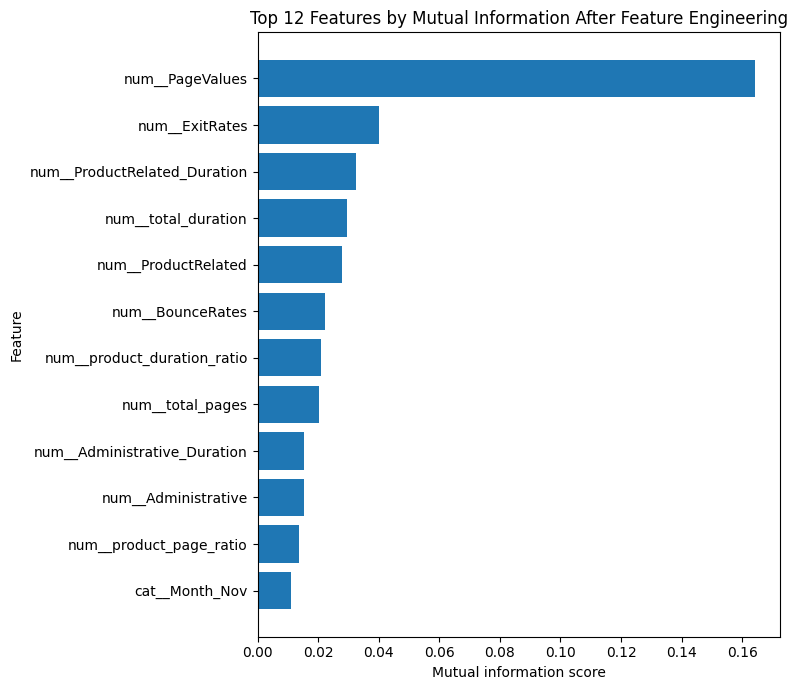

In [181]:
top_mi_engineered_features = mi_scores_engineered_df.head(12).sort_values("mutual_information")

plt.figure(figsize=(8, 7))
plt.barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"]
)
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 12 Features by Mutual Information After Feature Engineering")
plt.tight_layout()
plt.show()

The chart shows that `PageValues` remains clearly ahead of the other features. After that, the strongest group is made up of exit behaviour, product activity and the new engineered session summaries.

This is a useful result because all four engineered features appear in the top 12. It does not prove that the models will perform better, but it gives a reasonable reason to test the engineered feature set through the baseline and tuning stages.

### Baseline modelling with engineered features

The next step is to rerun the baseline models using the engineered feature set. This keeps the comparison fair, because the same modelling process is repeated after changing the input features.

In [182]:
engineered_baseline_results = []
engineered_trained_pipelines = {}
engineered_baseline_predictions = {}
engineered_baseline_confusion_matrices = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor_engineered)),
        ("model", clone(model))
    ])

    pipeline.fit(X_train_engineered, y_train_engineered)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_engineered,
        y_test_engineered
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline
    engineered_baseline_predictions[model_name] = y_pred
    engineered_baseline_confusion_matrices[model_name] = cm


Logistic Regression
Confusion matrix:
[[1761  298]
 [  75  307]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.86      0.90      2059
        True       0.51      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441


Decision Tree
Confusion matrix:
[[1897  162]
 [ 196  186]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.92      0.91      2059
        True       0.53      0.49      0.51       382

    accuracy                           0.85      2441
   macro avg       0.72      0.70      0.71      2441
weighted avg       0.85      0.85      0.85      2441


Random Forest
Confusion matrix:
[[1992   67]
 [ 195  187]]

Classification report:
              precision    recall  f1-score   support

       False       0.91      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [183]:
engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)

engineered_baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901680,0.712575,0.623037,0.664804
6,Hist Gradient Boosting,0.898812,0.702703,0.612565,0.654545
4,Support Vector Machine,0.863990,0.546468,0.769634,0.639130
0,Logistic Regression,0.847194,0.507438,0.803665,0.622087
2,Random Forest,0.892667,0.736220,0.489529,0.588050
7,MLPClassifier,0.872184,0.598870,0.554974,0.576087
1,Decision Tree,0.853339,0.534483,0.486911,0.509589
3,K-Nearest Neighbours,0.868497,0.624490,0.400524,0.488038


The engineered baseline results are similar to the first modelling cycle. Among the engineered baseline models, `Gradient Boosting` performs best on F1-score for the purchase class, with precision 0.712575, recall 0.623037 and F1-score 0.664804. `Hist Gradient Boosting` is close behind, with precision 0.702703, recall 0.612565 and F1-score 0.654545.

These results are useful, but they should not yet be compared directly with the tuned original-feature models. The current table shows untuned models using engineered features, while the previous comparison table shows tuned models using the original feature set. At this stage, the engineered features have not clearly improved performance on their own.

`Logistic Regression` has the highest recall in this engineered baseline run, at 0.803665, but its precision is much lower at 0.507438. `Support Vector Machine` also has strong recall at 0.769634, but lower precision than the boosting models. `Random Forest` has stronger precision at 0.736220, but weaker recall at 0.489529.

The next useful check is whether tuning the engineered-feature models can improve on the current benchmark, which is the original tuned `Random Forest` F1-score of 0.682051.

## Tuning engineered-feature models

The second tuning cycle focuses on `Gradient Boosting`, `Hist Gradient Boosting` and `Random Forest`. These are the strongest tree-based contenders and the most useful models to compare against the original-feature benchmark.

In [184]:
engineered_tuned_results = []
engineered_tuned_models = {}

### Gradient Boosting: strongest engineered baseline by F1.

In [185]:
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor",  clone(preprocessor_engineered)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_engineered_search = RandomizedSearchCV(
    gb_engineered_pipeline,
    param_distributions=gb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_engineered_search.fit(X_train_engineered, y_train_engineered)

print("Best parameters:")
print(gb_engineered_search.best_params_)

print("\nBest CV F1:")
print(gb_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 2, 'model__learning_rate': 0.1}

Best CV F1:
0.6568856771143644


In [186]:
gb_engineered_best_model = gb_engineered_search.best_estimator_

gb_engineered_results, gb_engineered_pred, gb_engineered_confusion = evaluate_model(
    "Tuned Gradient Boosting engineered",
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(gb_engineered_results)
engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model


Tuned Gradient Boosting engineered
Confusion matrix:
[[1965   94]
 [ 139  243]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.80      0.81      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Gradient Boosting` model with engineered features chose 100 estimators, a learning rate of 0.1, maximum depth of 2 and `min_samples_leaf` of 1. During cross-validation, the best F1-score was 0.656886.

On the test set, the model reached accuracy of 0.90, precision of 0.72, recall of 0.64 and F1-score of 0.68 for the purchase class. This is a stronger result than the earlier engineered Gradient Boosting baseline, so the tuning has improved the model’s ability to identify purchase sessions.

The confusion matrix shows 243 correctly predicted purchase sessions, but 139 purchase sessions were still missed. It also produced 94 false positives, where non-purchase sessions were incorrectly predicted as purchases. Using the engineered features has enabled an increased in purchase-class recall and F1-score, while keeping false positives relatively controlled.

### Hist Gradient Boosting: close engineered baseline and strong throughout.

In [187]:
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}

hgb_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_engineered)),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_engineered_search = RandomizedSearchCV(
    hgb_engineered_pipeline,
    param_distributions=hgb_engineered_param_grid,
    n_iter=8,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

hgb_engineered_search.fit(X_train_engineered, y_train_engineered)

print("Best parameters:")
print(hgb_engineered_search.best_params_)

print("\nBest CV F1:")
print(hgb_engineered_search.best_score_)

Best parameters:
{'model__max_leaf_nodes': 31, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}

Best CV F1:
0.6567095831580732


In [188]:
hgb_engineered_best_model = hgb_engineered_search.best_estimator_

hgb_engineered_results, hgb_engineered_pred, hgb_engineered_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting engineered",
    hgb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(hgb_engineered_results)
engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model


Tuned Hist Gradient Boosting engineered
Confusion matrix:
[[1964   95]
 [ 145  237]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.62      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Hist Gradient Boosting` model with engineered features chose 100 iterations, a learning rate of 0.05, 31 leaf nodes and no L2 regularisation. The best cross-validation F1-score was 0.656710.

On the test set, the model reached accuracy of 0.90, precision of 0.71, recall of 0.62 and F1-score of 0.66 for the purchase class. This is a reasonable result, but it is slightly weaker than the tuned `Gradient Boosting` model with engineered features, which reached a purchase-class F1-score of 0.68.

The confusion matrix shows that the model correctly predicted 237 purchase sessions and missed 145 purchase sessions. It also produced 95 false positives. Overall, the model performs well, but the engineered `Hist Gradient Boosting` tuning has not moved it ahead of `Gradient Boosting` in this cycle.

### Random Forest: strongest original tuned model and current benchmark to beat.

In [189]:
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced"]
}

rf_engineered_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor_engineered)),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_engineered_search = RandomizedSearchCV(
    rf_engineered_pipeline,
    param_distributions=rf_engineered_param_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_engineered_search.fit(X_train_engineered, y_train_engineered)

print("Best parameters:")
print(rf_engineered_search.best_params_)

print("\nBest CV F1:")
print(rf_engineered_search.best_score_)

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1:
0.6717104073192768


In [190]:
rf_engineered_best_model = rf_engineered_search.best_estimator_

rf_engineered_results, rf_engineered_pred, rf_engineered_confusion = evaluate_model(
    "Tuned Random Forest engineered",
    rf_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(rf_engineered_results)
engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model


Tuned Random Forest engineered
Confusion matrix:
[[1945  114]
 [ 133  249]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.69      0.65      0.67       382

    accuracy                           0.90      2441
   macro avg       0.81      0.80      0.80      2441
weighted avg       0.90      0.90      0.90      2441



The tuned `Random Forest` model with engineered features selected 200 trees, `max_depth` of 20, `max_features="sqrt"`, `min_samples_split` of 2, `min_samples_leaf` of 2 and balanced class weights. The best cross-validation F1-score was 0.671710.

On the test set, it reached accuracy of 0.90, precision of 0.69, recall of 0.65 and F1-score of 0.67 for the purchase class. This is a fairly balanced result, because both precision and recall are close to each other.

The confusion matrix shows 249 correctly predicted purchase sessions and 133 missed purchase sessions. It also produced 114 false positives. Compared with the tuned `Hist Gradient Boosting` model with engineered features, this model has higher recall and a slightly higher F1-score, although it has lower precision and more false positives. At this stage, `Random Forest` remains a strong contender, but the tuned `Gradient Boosting` model still has the highest purchase-class F1-score in the engineered feature cycle so far.

In [191]:
engineered_tuned_results_df = pd.DataFrame(engineered_tuned_results)

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
0,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939
2,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456
1,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866


The engineered tuning results show that `Gradient Boosting` is the strongest model in this second cycle. It achieved accuracy of 0.904547, precision of 0.721068, recall of 0.636126 and F1-score of 0.675939 for the purchase class.

`Random Forest` comes second, with an F1-score of 0.668456. Its recall is slightly higher than `Gradient Boosting`, at 0.651832, which means it identifies slightly more actual purchase sessions. However, its precision is lower, at 0.685950, so it also makes more false purchase predictions.

`Hist Gradient Boosting` is close behind, with an F1-score of 0.663866. It has precision of 0.713855 and recall of 0.620419, so it performs well but is slightly less balanced than the other two models in this comparison.

Within this engineered-feature tuning cycle, the three models are very close. However, `Gradient Boosting` is the strongest result in this table because it has the highest F1-score and the best overall balance between precision and recall.

## Final contender comparison

This section compares the strongest results from the main modelling stages: baseline models, tuned models using the original features, and tuned models using the engineered features.

In [192]:
baseline_comparison_df = baseline_results_df.copy()
original_tuned_comparison_df = tuned_results_df.copy()
engineered_tuned_comparison_df = engineered_tuned_results_df.copy()

baseline_comparison_df["stage"] = "Baseline"
baseline_comparison_df["feature_set"] = "Original features"

original_tuned_comparison_df["stage"] = "Tuned"
original_tuned_comparison_df["feature_set"] = "Original features"

engineered_tuned_comparison_df["stage"] = "Tuned"
engineered_tuned_comparison_df["feature_set"] = "Engineered features"

final_comparison_df = pd.concat(
    [
        baseline_comparison_df,
        original_tuned_comparison_df,
        engineered_tuned_comparison_df
    ],
    ignore_index=True
)

final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features
8,Tuned Gradient Boosting,0.904138,0.718935,0.636126,0.675000,Tuned,Original features
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157,Baseline,Original features
16,Tuned Random Forest engineered,0.898812,0.685950,0.651832,0.668456,Tuned,Engineered features
9,Tuned Hist Gradient Boosting,0.902909,0.719033,0.623037,0.667602,Tuned,Original features
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590,Baseline,Original features
15,Tuned Hist Gradient Boosting engineered,0.901680,0.713855,0.620419,0.663866,Tuned,Engineered features
10,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867,Tuned,Original features
11,Tuned Logistic Regression,0.872593,0.569745,0.759162,0.650954,Tuned,Original features


The comparison table shows that the strongest models are close, so the final choice should not be based on accuracy alone.

`Tuned Random Forest` using the original features has the strongest F1-score and recall. `Tuned Gradient Boosting engineered` is also strong and has higher precision. These two models are therefore carried forward as the final contenders.

### Selecting final contenders

The final contender analysis focuses on two models: `Tuned Random Forest` using the original features and `Tuned Gradient Boosting engineered` using the engineered feature set.

In [193]:
final_contender_names = [
    "Tuned Random Forest",
    "Tuned Gradient Boosting engineered"
]

top_contenders = final_comparison_df[
    final_comparison_df["model"].isin(final_contender_names)
].copy()

top_contenders.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
14,Tuned Gradient Boosting engineered,0.904547,0.721068,0.636126,0.675939,Tuned,Engineered features


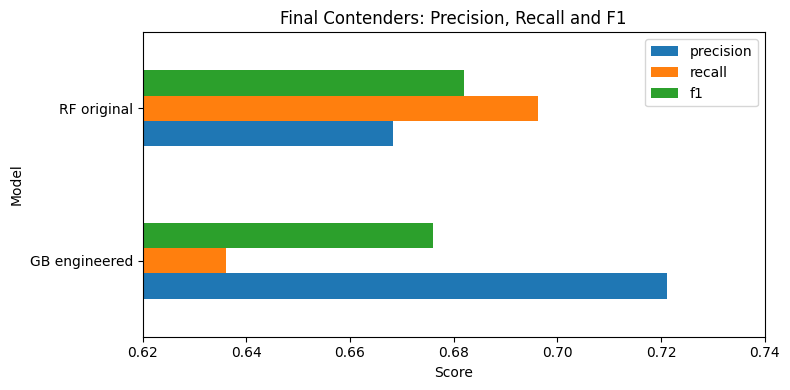

In [194]:
top_contenders_plot = top_contenders.copy()

top_contenders_plot["model"] = top_contenders_plot["model"].replace({
    "Tuned Random Forest": "RF original",
    "Tuned Gradient Boosting engineered": "GB engineered"
})

top_contenders_plot = top_contenders_plot.sort_values(by="f1", ascending=True)

top_contenders_plot.plot(
    x="model",
    y=["precision", "recall", "f1"],
    kind="barh",
    figsize=(8, 4)
)

# zoom in on the final-contender range so the trade-off is easier to compare
plt.xlim(0.62, 0.74)
plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Final Contenders: Precision, Recall and F1")
plt.tight_layout()
plt.show()

The chart shows the final trade-off clearly. `Tuned Random Forest` has stronger recall and F1-score, so it captures more actual purchase sessions.

`Tuned Gradient Boosting engineered` has stronger precision, so it is more selective when predicting purchases. The drawback is that it misses more actual purchase sessions.

## Confusion matrices for final contenders

In [195]:
rf_original_pred = rf_search.predict(X_test_original)
gb_engineered_pred = gb_engineered_best_model.predict(X_test_engineered)

rf_confusion_matrix = confusion_matrix(y_test_original, rf_original_pred)
gb_engineered_confusion_matrix = confusion_matrix(y_test_engineered, gb_engineered_pred)

print("Final contender 1: Tuned Random Forest using original features")
print(rf_confusion_matrix)

print("\nFinal contender 2: Tuned Gradient Boosting using engineered features")
print(gb_engineered_confusion_matrix)

Final contender 1: Tuned Random Forest using original features
[[1927  132]
 [ 116  266]]

Final contender 2: Tuned Gradient Boosting using engineered features
[[1965   94]
 [ 139  243]]


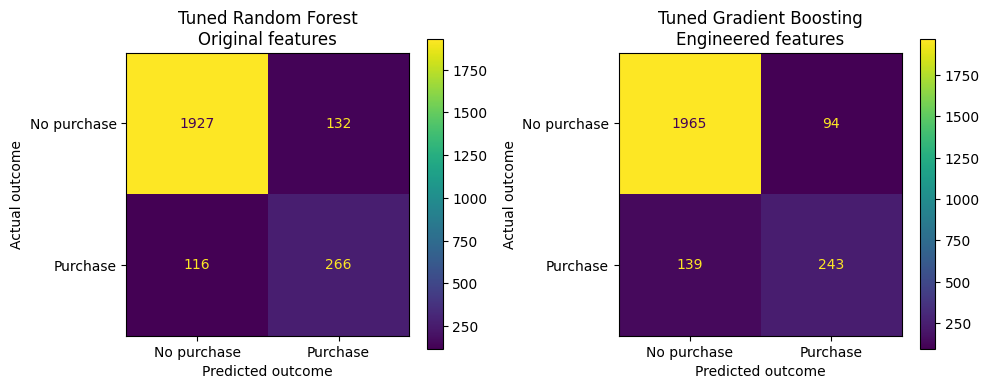

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_original,
    rf_original_pred,
    display_labels=["No purchase", "Purchase"],
    ax=axes[0],
    values_format="d"
)
axes[0].set_title("Tuned Random Forest\nOriginal features")
axes[0].set_xlabel("Predicted outcome")
axes[0].set_ylabel("Actual outcome")

ConfusionMatrixDisplay.from_predictions(
    y_test_engineered,
    gb_engineered_pred,
    display_labels=["No purchase", "Purchase"],
    ax=axes[1],
    values_format="d"
)
axes[1].set_title("Tuned Gradient Boosting\nEngineered features")
axes[1].set_xlabel("Predicted outcome")
axes[1].set_ylabel("Actual outcome")

plt.tight_layout()
plt.show()

The confusion matrices show the types of error made by each final contender.

`Tuned Random Forest` correctly identifies more purchase sessions and misses fewer actual purchasers. The cost is that it creates more false positives.

`Tuned Gradient Boosting engineered` creates fewer false positives, so its purchase predictions are more selective. The cost is that it misses more actual purchasers.

## Permutation importance

The score table and confusion matrices show how well the final contenders perform, but they do not show which features are most important to the predictions.

Permutation importance is used here to check which features each final contender relies on most, and whether the engineered features add meaningful value.

In [197]:
rf_perm_importance = permutation_importance(
    rf_search,
    X_test_original,
    y_test_original,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_importance_df = pd.DataFrame({
    "feature": X_test_original.columns,
    "importance_mean": rf_perm_importance.importances_mean,
    "importance_std": rf_perm_importance.importances_std
})

rf_importance_df = rf_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

rf_importance_df.head(10)

,feature,importance_mean,importance_std
8,PageValues,0.472413,0.013380
7,ExitRates,0.043457,0.018587
10,Month,0.020181,0.008444
4,ProductRelated,0.013553,0.003084
5,ProductRelated_Duration,0.009030,0.008174
14,TrafficType,0.007603,0.002879
16,Weekend,0.004966,0.003204
6,BounceRates,0.004545,0.008105
2,Informational,0.004149,0.002716
0,Administrative,0.002998,0.004073


In [198]:
gb_engineered_perm_importance = permutation_importance(
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_engineered_importance_df = pd.DataFrame({
    "feature": X_test_engineered.columns,
    "importance_mean": gb_engineered_perm_importance.importances_mean,
    "importance_std": gb_engineered_perm_importance.importances_std
})

gb_engineered_importance_df = gb_engineered_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

gb_engineered_importance_df.head(10)

,feature,importance_mean,importance_std
8,PageValues,0.502893,0.014679
10,Month,0.041324,0.009141
7,ExitRates,0.021838,0.006654
6,BounceRates,0.013687,0.005345
5,ProductRelated_Duration,0.008047,0.003027
0,Administrative,0.007200,0.006096
4,ProductRelated,0.005531,0.001957
17,total_pages,0.003216,0.003614
20,product_duration_ratio,0.002622,0.003239
18,total_duration,0.002318,0.003661


The permutation importance results show that `PageValues` is by far the most influential feature for both final contenders. When this feature is shuffled, each model’s F1-score drops much more than for any other feature. This suggests that both models rely heavily on whether a session contains pages with stronger purchase value.

For `Tuned Random Forest`, the next most important features are `ExitRates`, `Month`, `ProductRelated` and `ProductRelated_Duration`. These are mainly browsing-behaviour and session-context variables.

For `Tuned Gradient Boosting engineered`, the next strongest features are `Month`, `ExitRates`, `BounceRates` and `ProductRelated_Duration`. Some engineered features appear in the top ten, including `total_pages`, `product_duration_ratio` and `total_duration`, but their importance scores are relatively small.

Because `PageValues` dominates the scale of the results, the following chart excludes it and focuses on the secondary features. This makes the smaller differences between the two final contenders easier to compare.

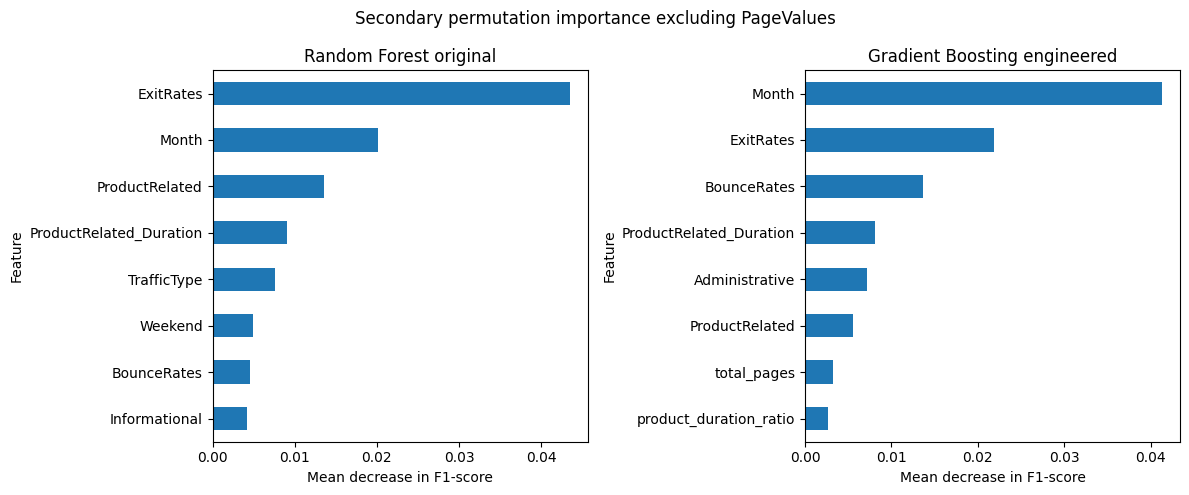

In [199]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rf_secondary_importance = rf_importance_df[
    rf_importance_df["feature"] != "PageValues"
].head(8).sort_values(
    by="importance_mean",
    ascending=True
)

gb_secondary_importance = gb_engineered_importance_df[
    gb_engineered_importance_df["feature"] != "PageValues"
].head(8).sort_values(
    by="importance_mean",
    ascending=True
)

rf_secondary_importance.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[0]
)

gb_secondary_importance.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[1]
)

axes[0].set_title("Random Forest original")
axes[0].set_xlabel("Mean decrease in F1-score")
axes[0].set_ylabel("Feature")

axes[1].set_title("Gradient Boosting engineered")
axes[1].set_xlabel("Mean decrease in F1-score")
axes[1].set_ylabel("Feature")

plt.suptitle("Secondary permutation importance excluding PageValues")
plt.tight_layout()
plt.show()

The secondary feature-importance chart shows that the two contenders use the remaining features differently. `Tuned Random Forest` places most secondary importance on `ExitRates`, while `Tuned Gradient Boosting engineered` places most secondary importance on `Month`.

The engineered features are present in the `Gradient Boosting` ranking, but they are not among the strongest secondary signals. This suggests that the engineered features add some useful information, but the main predictive signal still comes from the original browsing and session variables.

## Final model choice

The final two contenders are close, so the decision is not based on one score in isolation. Accuracy is shown for context, but F1-score and recall matter more because the dataset is imbalanced and the purchase class is the minority class.

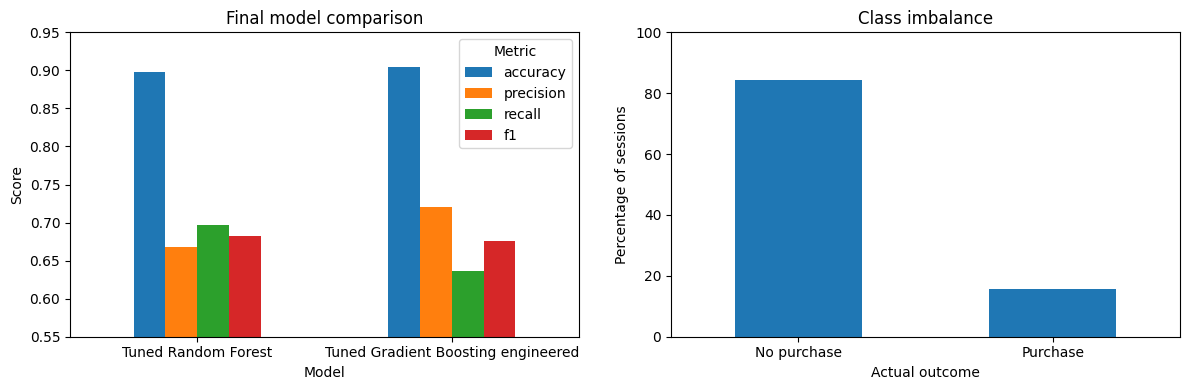

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

final_model_plot_df = final_model_choice_df.set_index("model")[
    ["accuracy", "precision", "recall", "f1"]
]

final_model_plot_df.plot(
    kind="bar",
    ax=axes[0],
    rot=0
)

axes[0].set_ylim(0.55, 0.95)
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Model")
axes[0].set_title("Final model comparison")
axes[0].legend(title="Metric")

class_balance = y.value_counts(normalize=True).sort_index() * 100
class_balance.index = ["No purchase", "Purchase"]

class_balance.plot(
    kind="bar",
    ax=axes[1],
    rot=0
)

axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percentage of sessions")
axes[1].set_xlabel("Actual outcome")
axes[1].set_title("Class imbalance")

plt.tight_layout()
plt.show()

In [201]:
final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

rf_tn, rf_fp, rf_fn, rf_tp = rf_confusion_matrix.ravel()
gb_tn, gb_fp, gb_fn, gb_tp = gb_engineered_confusion_matrix.ravel()

final_model_choice_df["false_positives"] = final_model_choice_df["model"].map({
    "Tuned Random Forest": rf_fp,
    "Tuned Gradient Boosting engineered": gb_fp
})

final_model_choice_df["missed_purchases"] = final_model_choice_df["model"].map({
    "Tuned Random Forest": rf_fn,
    "Tuned Gradient Boosting engineered": gb_fn
})

final_model_choice_df = final_model_choice_df.sort_values(
    by="f1",
    ascending=False
)

final_model_choice_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}"
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1"],
    color="lightblue"
)

,model,feature_set,accuracy,precision,recall,f1,false_positives,missed_purchases
12,Tuned Random Forest,Original features,0.898,0.668,0.696,0.682,132,116
14,Tuned Gradient Boosting engineered,Engineered features,0.905,0.721,0.636,0.676,94,139


The main difference is the type of error each model makes. `Tuned Random Forest` has the stronger F1-score and recall, so it finds more of the sessions that actually end in a purchase.

`Tuned Gradient Boosting engineered` has stronger precision, so it produces fewer false positives. The downside is that it misses more real purchasers.

For this notebook, `Tuned Random Forest` is selected as the final model. The F1-score improvement is small, but it is paired with better recall and fewer missed purchases, which fits a purchase-intention task where identifying potential purchasers is the priority.

## Limitations and possible improvements

The final results depend strongly on `PageValues`, which is by far the most important feature in both final contenders. This should be checked carefully in a real deployment because the feature may not always be available at the intended prediction point.

Future improvements could include threshold tuning, probability calibration and testing the final model on another split or external dataset.

## Notebook summary

This notebook built and compared supervised classification models for predicting online purchase intention.

The workflow included data inspection, preprocessing, feature selection, baseline modelling, tuning, feature engineering, final contender comparison, permutation importance and final model selection.

`Tuned Random Forest` was selected because it gave the strongest F1-score and identified more actual purchase sessions than the engineered `Gradient Boosting` alternative.